---
Documentação geral, metodologia, estruturação e manual de utilização do código, licença MIT de uso e outras características pode ser acessada pelo link: https://github.com/OAkacio/HoggCosmoMeasures  🌌

# ***Integração Numérica da Distância de Luminosidade pela Métrica de Hogg em Modelos FLRW***

Este notebook apresenta a rotina de integração numérica para o cálculo da Distância de Luminosidade ($D_L$) e do Módulo de Distância ($\mu$) baseada na formulação de Hogg para modelos cosmológicos de Friedmann-Lemaître-Robertson-Walker (FLRW).

---

# **Fundamentação Teórica e Estatística**

A base matemática apoia-se nas definições cosmológicas clássicas para um universo homogêneo e isotrópico. A rotina processa as seguintes grandezas em cascata:

**1. Função de Expansão de Hubble ($E(z)$):** Descreve a evolução temporal da taxa de expansão em função da densidade de matéria ($\Omega_m$), curvatura espacial ($\Omega_k$), energia escura ($\Omega_{EE}$) e seu parâmetro de estado $w$:

$$E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_k(1+z)^2 + \Omega_{EE}(1+z)^{3(1+w)}}$$

**2. Distância Comóvel Radial ($D_C$):** É a coordenada central do nosso integrador, representando a distância no tempo de olhar para trás (lookback time) na linha de visada:

$$D_C = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$$

**3. Distância Comóvel Transversal ($D_M$):** Inclui os efeitos da geometria global. Utilizando a distância de Hubble $D_H = c/H_0$ e a relação $\Omega_k = 1 - \Omega_m - \Omega_{EE}$:

$$D_M = \begin{cases} \frac{D_H}{\sqrt{\Omega_k}} \sinh\left(\sqrt{\Omega_k} \frac{D_C}{D_H}\right) & \text{se } \Omega_k > 0 \text{ (Universo Aberto)} \\ D_C & \text{se } \Omega_k = 0 \text{ (Universo Plano)} \\ \frac{D_H}{\sqrt{|\Omega_k|}} \sin\left(\sqrt{|\Omega_k|} \frac{D_C}{D_H}\right) & \text{se } \Omega_k < 0 \text{ (Universo Fechado)} \end{cases}$$

**4. Distância de Luminosidade ($D_L$) e Módulo de Distância ($\mu$)** Conecta o fluxo fotônico recebido à luminosidade intrínseca da vela padrão:

$$D_L = (1+z) D_M$$

A conversão logarítmica resulta no Módulo de Distância ($\mu$), nossa principal observável:

$$\mu = 5 \log_{10}\left(D_L\right) + 25$$

**5. Inferência de Parâmetros e Maximização da Verossimilhança ($\chi^2$)** Para adequar a teoria aos dados, o código computa o qui-quadrado sobre os erros observacionais gaussianos ($\sigma_{\mu_i}$):

$$\chi^2 = \sum_{i} \frac{[\mu_{obs}(z_i) - \mu_{teo}(z_i, \Omega_M, \Omega_{EE}, w)]^2}{\sigma_{\mu_i}^2}$$

Os intervalos de confiança são construídos assumindo que a densidade de probabilidade distribui-se como $P \propto \exp(-\chi^2/2)$. O conjunto de análise também suporta quebra de degenerescência adicionando termos de *prior*, como o limite da Radiação Cósmica de Fundo (CMB).

# ***IMPLEMENTAÇÃO DE FUNÇÕES FUNDAMENTAIS***
---
 * Desenvolvimento dos algoritmos matemáticos e físicos que sustentam os cálculos do modelo cosmológico.

## ***Bibliotecas e Dependências***
---
 * Importação das ferramentas de cálculo numérico, integração, constantes astronômicas e visualização de dados.

In [1]:
!git clone https://github.com/OAkacio/toolkit.git
import sys
if '/content' not in sys.path:
    sys.path.append('/content')


from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.integrate import quad
from pathlib import Path as path
from matplotlib.ticker import AutoMinorLocator
import toolkit.system as sy
import toolkit.saveload as sl
import toolkit.graphs as gp

Cloning into 'toolkit'...
c:\Users\victo\Documents\Repositórios GitHub\Hogg\HoggCosmoMeasures\notebooks\toolkit\graphs.py:376: SyntaxWarning: invalid escape sequence '\c'
  """


## ***Parâmetros INPUTS*** | _(parameters.py)_
---
 * Definição das variáveis iniciais e de ajuste para todos os códigos.

In [2]:

# * =============================================================================
# * PARÂMETROS INICIAIS
# * =============================================================================

Omega_M = 0.315  # Densidade de matéria [adm.]
Omega_EE = 0.685  # Densidade de energia escura [adm.]
w = -1  # Parâmetro de equação de estado da energia escura [adm.]
z = 6  # Redshift máximo [adm.]

# * =============================================================================
# * PARÂMETROS DE ANÁLISE
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         MAIN
# ? -----------------------------------------------------------------------------

z_step = 1e-5  # Intervalo entre um ponto e outro nos dados

# ? -----------------------------------------------------------------------------
# ?         INFERENCE
# ? -----------------------------------------------------------------------------

mesh_inter_omega = [0, 1]  # Intervalo de análise [omega_ini, omega_fin]
mesh_inter_w = [-1.25, 0.25]  # Intervalo de análise [w_ini, w_fin]
meshgrid_step = 5e-3  # Intervalo entre um ponto e outro nos dados
Omega_K_obs = -0.06  # Parâmetro de Densidade da Curvatura observado
ERROOmega_K_obs = 0.05  # Erro do Parâmetro de Densidade da Curvatura observado


## ***Constantes Físicas*** | _(constants.py)_
---
 * Definição das constantes fundamentais, como a velocidade da luz e a constante de Hubble, utilizadas como base para os cálculos cosmológicos.

In [3]:

# * =============================================================================
# * CONSTANTES FÍSICAS
# * =============================================================================

H0 = 70  # Constante de Hubble [km/s/Mpc]
c = const.c.to("km/s").value  # Velocidade da luz [km/s]


## ***Núcleo Matemático*** | _(core.py)_
---
 * Implementação das equações analíticas e métodos de integração para a determinação de parâmetros físicos.

In [4]:

# * =============================================================================
# * FUNÇÕES MATEMÁTICAS
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES FÍSICAS
# ? -----------------------------------------------------------------------------


def q0(Omega_M, Omega_EE, w):
    """Calcula o parâmetro de desaceleração atual (q0) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 0.5 * Omega_M + 0.5 * Omega_EE * (1 + 3 * w)


def dL(Omega_M, Omega_EE, resint, z):
    """Calcula a distância de luminosidade (dL) a partir da distância comóvel transversal (dm) e do redshift (z)."""
    return (1 + z) * dm(Omega_M, Omega_EE, resint)


def approx_dL(Omega_M, Omega_EE, z, w):
    """Calcula a aproximação de distância de luminosidade (dL) para pequenos redshifts (z) usando o parâmetro de desaceleração (q0)."""
    return (c / H0) * z * (1 + (1 - q0(Omega_M, Omega_EE, w)) * z / 2)


def Omega_K(Omega_M, Omega_EE):
    """Calcula o parâmetro de curvatura (Omega_K) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 1 - (Omega_M + Omega_EE)


def mu(Omega_M, Omega_EE, resint, z):
    """Calcula a magnitude de distância (mu) a partir da distância de luminosidade (dL) e do redshift (z)."""
    return 5 * np.log10(dL(Omega_M, Omega_EE, resint, z)) + 25


def E(z, Omega_M, Omega_EE, w):
    """Calcula a função de expansão (E) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return np.sqrt(
        Omega_M * (1 + z) ** 3
        + Omega_EE * (1 + z) ** (3 * (1 + w))
        + Omega_K(Omega_M, Omega_EE) * (1 + z) ** 2
    )


def Sk(Omega_M, Omega_EE, r):
    """Calcula a função de distância comóvel transversal (Sk) a partir do parâmetro de curvatura (k) e da distância comóvel radial (r)."""
    Ok = Omega_K(Omega_M, Omega_EE)
    DH = c / H0
    if Ok > 0:
        return (DH / np.sqrt(Ok)) * np.sinh(np.sqrt(Ok) * r / DH)
    elif Ok < 0:
        return (DH / np.sqrt(-Ok)) * np.sin(np.sqrt(-Ok) * r / DH)
    else:
        return r


def dm(Omega_M, Omega_EE, resint):
    """Calcula a distância comóvel transversal (dm) a partir do parâmetro de curvatura (k) e da distância comóvel radial (dC)."""
    return Sk(Omega_M, Omega_EE, dC(resint))


def dC(resint):
    """Calcula o valor de distância comóvel radial (dC) a partir do resultado da integração dda função integral."""
    return (c / H0) * resint


def k(Omega_M, Omega_EE):
    """Determina o parâmetro de curvatura com base no valor do Parâmetro de Densidade de Curvatura (Omega_k)"""
    Ok = Omega_K(Omega_M, Omega_EE)
    if Ok > 0:
        return -1
    elif Ok < 0:
        return +1
    else:
        return 0


# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES SISTEMÁTICAS DE CÁLCULO NO MAIN
# ? -----------------------------------------------------------------------------


def integral(z, Omega_M, Omega_EE, w):
    """Formaliza a quantidade a ser integrada para o cálculo da distância comóvel radial (dC) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return 1 / E(z, Omega_M, Omega_EE, w)


def integracao(integral, Omega_M, Omega_EE, z, w):
    IntANDError = quad(integral, 0, z, args=(Omega_M, Omega_EE, w))
    resint = IntANDError[0]
    ERRORresint = IntANDError[1]
    return [resint, ERRORresint]


def UniType(Omega_k):
    """Determina o tipo de universo estudado baseado no valor do Parâmetro de Densidade de Curvatura(Omega_k)"""
    if Omega_k > 0:
        return "Universo Aberto"
    elif Omega_k < 0:
        return "Universo Fechado"
    else:
        return "Universo Plano"


def solution(Omega_M, Omega_EE, z, z_step, w):
    """Função que calcula uma matriz de resultados de distância de luminosidade (dL), módulo de distância (mu), distância de luminosidade aproximada (dLAP) e diferença entre as duas (DIF) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura em um passo (z_step)."""
    DLvectorX = []
    DLvectorY = []
    MUvectorX = []
    MUvectorY = []
    DLAPvectorX = []
    DLAPvectorY = []
    DIFvectorX = []
    DIFvectorY = []
    for i in tqdm(np.arange(float(z_step), float(z) + float(z_step), float(z_step))):
        iresint = integracao(integral, Omega_M, Omega_EE, i, w)
        DLvectorX.append(i)
        DLvectorY.append(dL(Omega_M, Omega_EE, iresint[0], i))
        MUvectorX.append(i)
        MUvectorY.append(mu(Omega_M, Omega_EE, iresint[0], i))
        DLAPvectorX.append(i)
        DLAPvectorY.append(approx_dL(Omega_M, Omega_EE, i, w))
        if i <= 1:
            DIFvectorX.append(i)
            DIFvectorY.append((DLvectorY[-1] - DLAPvectorY[-1])/DLvectorY[-1])
    return [
        DLvectorX,
        DLvectorY,
        MUvectorX,
        MUvectorY,
        DLAPvectorX,
        DLAPvectorY,
        DIFvectorX,
        DIFvectorY,
    ]


# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES SISTEMÁTICAS DE CÁLCULO NO INFERENCE
# ? -----------------------------------------------------------------------------


def chi2(mu_obs_list, ERROmu_obs_list, mu_teo_list):
    """Função responsável por calcular o qui-quadrado para uma lista de módulos de distância (mu) observados (mu_obs_list), seus erros (ERROmu_obs_list) e os módulos de distância teoricos (mu_teo_list)."""
    x = (mu_obs_list - mu_teo_list) / (ERROmu_obs_list)
    return np.sum(x**2)


def malha_mu_teo(Omega_M, Omega_EE, z_list, w):
    """Função responsável por calcular uma lista de módulos de distância (mu) teoricos para uma lista de redshifts (z_list)."""
    mu_teo_list = []
    for z in z_list:
        mu_teo_list.append(
            mu(
                Omega_M,
                Omega_EE,
                integracao(integral, Omega_M, Omega_EE, z, w)[0],
                z,
            )
        )
    return mu_teo_list


def varredura_1D(omega_list, mu_obs_list, ERROmu_obs_list, z_list, w):
    """Função responsável por realizar uma varredura 1D (Universo Plano) para calcular o qui-quadrado para uma lista de módulos de distância (mu) observados (mu_obs_list), seus erros (ERROmu_obs_list) e os módulos de distância teoricos (mu_teo_list)."""
    chi2_list = []
    for om in tqdm(omega_list, desc="PROGRESSO"):
        oee = 1 - om
        chi2_list.append(
            chi2(mu_obs_list, ERROmu_obs_list, malha_mu_teo(om, oee, z_list, w))
        )
    return [chi2_list, omega_list, 1 - np.array(omega_list)]


def varredura_2D(omegaM_list, omegaEE_list, mu_obs_list, ERROmu_obs_list, z_list, w):
    """Função responsável por realizar uma varredura 2D (Universo com Curvatura Livre) para calcular o qui-quadrado para uma lista de módulos de distância (mu) observados (mu_obs_list), seus erros (ERROmu_obs_list) e os módulos de distância teoricos (mu_teo_list)."""
    matriz_chi2 = np.zeros((len(omegaM_list), len(omegaEE_list)))
    for i, om in enumerate(tqdm(omegaM_list, desc="PROGRESSO")):
        for j, oee in enumerate(omegaEE_list):
            mu_teorico = malha_mu_teo(om, oee, z_list, w)
            matriz_chi2[i, j] = chi2(mu_obs_list, ERROmu_obs_list, mu_teorico)
    return matriz_chi2


def quebra_degenerecencia(
    omegaM_list, omegaEE_list, matriz_sn, omegaK_obs, ERROomegaK_obs
):
    """
    Aplica o Prior da CMB sobre a matriz de Chi2 das Supernovas.
    ok_obs e sigma_ok devem seguir o roteiro do IAG (geralmente Planck).
    """
    matriz_total = np.zeros_like(matriz_sn)
    for i, om in enumerate(omegaM_list):
        for j, oee in enumerate(omegaEE_list):
            ok_teo = 1 - (om + oee)
            chi2_cmb = ((ok_teo - omegaK_obs) ** 2) / (ERROomegaK_obs**2)
            matriz_total[i, j] = matriz_sn[i, j] + chi2_cmb
    return matriz_total


def veross1d(chi2_list, chi_min, omegaEE_list):
    """Calcula a probabilidade de Omega_EE > 0.5 para o caso 1D (Universo Plano)."""
    L_vector = np.exp(-(np.array(chi2_list) - chi_min) / 2)
    mask_ee = np.array(omegaEE_list) > 0.5
    soma_total = np.sum(L_vector)
    soma_ee_05 = np.sum(L_vector[mask_ee])
    prob_ee = soma_ee_05 / soma_total
    return prob_ee


def veross2d(var2dPRIOR, chi2d_minPRIOR, omegaM_list, omegaEE_list, w):
    """Função responsável por calcular a probabilidade de aceleração para o universo com curvatura livre."""
    L_matrix = np.exp(-(var2dPRIOR - chi2d_minPRIOR) / 2)
    OM, OEE = np.meshgrid(omegaM_list, omegaEE_list, indexing="ij")
    mask_acel = q0(OM, OEE, w) < 0
    soma_total = np.sum(L_matrix)
    soma_acelerada = np.sum(L_matrix[mask_acel])
    prob_aceleracao = soma_acelerada / soma_total
    return prob_aceleracao


def varreduraOW(w_list, omegaM_list, mu_obs_list, ERROmu_obs_list, z_list):
    """Função responsável por gerar uma matriz de chi2 para cada combinação de omega_M e w para um universo plano."""
    matriz_chi2 = np.zeros((len(w_list), len(omegaM_list)))
    for i, w in enumerate(tqdm(w_list, desc="PROGRESSO")):
        for j, om in enumerate(omegaM_list):
            oe = 1 - om
            mu_teorico = malha_mu_teo(om, oe, z_list, w)
            matriz_chi2[i, j] = chi2(mu_obs_list, ERROmu_obs_list, mu_teorico)
    return matriz_chi2


# ***INÍCIO DA EXECUÇÃO***
---

## ***Função de Simulação Principal*** | _(main.py)_
---
 * Função responsável por receber um conjunto de parâmetros $(\Omega_m, \Omega_\Lambda , z)$ para exportar dados dos universos simulados.
 * A função também tem um _input_ oculto: $type$, para uso interno do algorítmo, sendo responsável por diferenciar uma execução direta do _main_ ou por fonte externa.

In [5]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================


def main(Omega_M, Omega_EE, w, z, type="return"):
    sy.header(
        "iniciando HoggCosmoMeasures...", Omega_M=Omega_M, Omega_EE=Omega_EE, w=w, z=z
    )

    # ? -----------------------------------------------------------------------------
    # ?         CÁLCULO DE PARÂMETROS PONTUAIS
    # ? -----------------------------------------------------------------------------

    try:
        sy.status("Iniciando processo de integração numérica para parâmetros pontuais")
        resintlist = integracao(integral, Omega_M, Omega_EE, z, w)
        sy.param(
            ("Integração Numérica", resintlist[0], "Mpc"),
            ("Erro Estimado", resintlist[1], "Mpc"),
            (
                "Distância de Luminosidade para (dL(z))",
                dL(Omega_M, Omega_EE, resintlist[0], z),
                "Mpc",
            ),
            (
                "Módulo de Distância (mu(z))",
                mu(Omega_M, Omega_EE, resintlist[0], z),
                "mag",
            ),
        )
    except Exception as e:
        sy.ok(f"Processo de integração numérica falhou! Erro: {e}...", False)
    try:
        sy.status("Iniciando cálculo de parâmetros do universo")
        sy.param(
            ("Tipo de universo", UniType(Omega_K(Omega_M, Omega_EE)), "adm."),
            ("Constante de curvatura espacial (k)", k(Omega_M, Omega_EE), "adm."),
            (
                "Parâmetro derivado de curvatura (Omega_K)",
                Omega_K(Omega_M, Omega_EE),
                "adm.",
            ),
            ("Distância comóvel radial (dC)", dC(resintlist[0]), "Mpc"),
            ("Parâmetro de desaceleração (q0)", q0(Omega_M, Omega_EE, w), "adm."),
        )
    except Exception as e:
        sy.ok(
            f"Processo de cálculo de parâmetros do universo falhou! Erro: {e}...", False
        )

    # ? -----------------------------------------------------------------------------
    # ?         CÁLCULO DE PARÂMETROS PARA TODO O INTERVALO
    # ? -----------------------------------------------------------------------------

    try:
        sy.status("Iniciando integração por todo o intervalo de redshift...")
        sollist = solution(Omega_M, Omega_EE, z, z_step, w)
        DLvectorX = sollist[0]
        DLvectorY = sollist[1]
        MUvectorX = sollist[2]
        MUvectorY = sollist[3]
        DLAPvectorX = sollist[4]
        DLAPvectorY = sollist[5]
        DIFvectorX = sollist[6]
        DIFvectorY = sollist[7]

        # ? -----------------------------------------------------------------------------
        # ?         EXPORTAÇÃO DE DADOS
        # ? -----------------------------------------------------------------------------

        if type == "custom":
            sy.status("Iniciando exportação de dados...")
            sl.savetable("infos", ((Omega_M, Omega_EE, w, z), ("", "", "", "")))
            sl.savetable("DLdados", (DLvectorX, DLvectorY))
            sl.savetable("MUdados", (MUvectorX, MUvectorY))
            sl.savetable("DLAPdados", (DLAPvectorX, DLAPvectorY))
            sl.savetable("DIFdados", (DIFvectorX, DIFvectorY))
            sy.ok(("infos", "DLdados", "MUdados", "DLAPdados", "DIFdados"))
        elif type == "M":
            sy.status("Iniciando exportação de dados")
            sy.status("Iniciando exportação de dados...")
            sl.savetable("infosM", ((Omega_M, Omega_EE, w, z), ("", "", "", "")))
            sl.savetable("DLdadosM", (DLvectorX, DLvectorY))
            sl.savetable("MUdadosM", (MUvectorX, MUvectorY))
            sl.savetable("DLAPdadosM", (DLAPvectorX, DLAPvectorY))
            sl.savetable("DIFdadosM", (DIFvectorX, DIFvectorY))
            sy.ok(("infosM", "DLdadosM", "MUdadosM", "DLAPdadosM", "DIFdadosM"))
        elif type == "EE":
            sy.status("Iniciando exportação de dados")
            sy.status("Iniciando exportação de dados...")
            sl.savetable("infosEE", ((Omega_M, Omega_EE, w, z), ("", "", "", "")))
            sl.savetable("DLdadosEE", (DLvectorX, DLvectorY))
            sl.savetable("MUdadosEE", (MUvectorX, MUvectorY))
            sl.savetable("DLAPdadosEE", (DLAPvectorX, DLAPvectorY))
            sl.savetable("DIFdadosEE", (DIFvectorX, DIFvectorY))
            sy.ok(("infosEE", "DLdadosEE", "MUdadosEE", "DLAPdadosEE", "DIFdadosEE"))
        elif type == "return":
            sy.status("EXECUÇÃO FINALIZADA!")
            return [
                dL(Omega_M, Omega_EE, resintlist[0], z),
                mu(Omega_M, Omega_EE, resintlist[0], z),
            ]
        sy.fim()
    except Exception as e:
        sy.ok(f"Falha no processo de salvamento! Erro: {e}...", False)


# ? -----------------------------------------------------------------------------
# ?         MAIN GUARD
# ? -----------------------------------------------------------------------------


if __name__ == "__main__":
    main(Omega_M, Omega_EE, w, z, type="custom")





╔══════════════════════════════════════════════════════════════════════════════╗
║                        INICIANDO HOGGCOSMOMEASURES...                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║            OMEGA_M: 0.315  |  OMEGA_EE: 0.685  |  W: -1  |  Z: 6             ║
╚══════════════════════════════════════════════════════════════════════════════╝



  » Iniciando processo de integração numérica para parâmetros pontuais
      Integração Numérica                    =   1.8939210608230983 [Mpc]
      Erro Estimado                          = 8.68159583178663e-11 [Mpc]
      Distância de Luminosidade para (dL(z)) =   56778.325008212414 [Mpc]
      Módulo de Distância (mu(z))            =    48.77091288226476 [mag]

  » Iniciando cálculo de parâmetros do universo
      Tipo de universo                          =      Universo Plano [adm.]
      Constante de curvatura espacial (k)       =                   0 [adm.]
      Parâmetro der

  0%|          | 0/600000 [00:00<?, ?it/s]


  » Iniciando exportação de dados...
            » [OK]   infos
            » [OK]   DLdados
            » [OK]   MUdados
            » [OK]   DLAPdados
            » [OK]   DIFdados

     »»»» EXECUÇÃO FINALIZADA!



## ***Função de Análise Individual do Universo Simulado*** | _(single_universe_plot.py)_
---
 * Função responsável por ler os dados gerados pela função principal e criar gráficos dos parâmetros calculados para o universo simulado.

In [6]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

sy.header("Análise de Universo Simulado", Folder="/data/...")

# ? -----------------------------------------------------------------------------
# ?         CARREGANDO DADOS DO UNIVERSO SIMULADO
# ? -----------------------------------------------------------------------------

try:
    sy.status("Iniciando carregamento de dados...")
    DLvectorX = sl.loadtable(f"data/DLdados.txt")[0]
    DLAPvectorX = sl.loadtable(f"data/DLAPdados.txt")[0]
    DIFvectorX = sl.loadtable(f"data/DIFdados.txt")[0]
    MUvectorX = sl.loadtable(f"data/MUdados.txt")[0]
    DLvectorY = sl.loadtable(f"data/DLdados.txt")[1]
    DLAPvectorY = sl.loadtable(f"data/DLAPdados.txt")[1]
    DIFvectorY = sl.loadtable(f"data/DIFdados.txt")[1]
    MUvectorY = sl.loadtable(f"data/MUdados.txt")[1]
    infos = sl.loadtable(f"data/infos.txt")[0]
    sy.ok(("infos", "DLdados", "MUdados", "DLAPdados", "DIFdados"))
    sy.status("Dados carregados com sucesso!")
    sy.param(
        ("Omega_M", infos[0]), ("Omega_EE", infos[1]), ("w", infos[2]), ("z", infos[3])
    )

    # ? -----------------------------------------------------------------------------
    # ?         GERANDO GRÁFICOS DE PARÂMETROS
    # ? -----------------------------------------------------------------------------

    sy.status("Iniciando criação do gráficos...")
    gp.basic(
        x_data=DLvectorX,
        y_data=DLvectorY / (c / H0),
        title="",
        x_label=r"$z$",
        y_label=r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        save_fig=True,
        filename="DLdistribuicao",
        show_plot=False,
    )
    gp.multi(
        x_list=(
            DLvectorX,
            DLAPvectorX,
        ),
        y_list=(DLvectorY / (c / H0), DLAPvectorY / (c / H0)),
        title="",
        x_label=r"$z$",
        y_label=r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        curve_names=("Curva Exata", "Curva Aproximada"),
        save_fig=True,
        filename="ExataAproximadadistribuicao",
        show_plot=False,
    )
    gp.multi(
        x_list=(DIFvectorX, DIFvectorX),
        y_list=(DIFvectorY, np.full(len(DIFvectorY), 0)),
        title="",
        x_label=r"$z$",
        y_label=r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        curve_names=("Diferença Exato vs. Aproximado", "Zero"),
        save_fig=True,
        filename="DIFdistribuicao",
        show_plot=False,
    )
    gp.basic(
        x_data=MUvectorX,
        y_data=MUvectorY,
        title="",
        x_label=r"$z$",
        y_label=r"$\mu$ (mag)",
        save_fig=True,
        filename="MUdistribuicao",
        show_plot=False,
    )
    sy.ok(
        (
            "Gráfico de Distância de Luminosidade",
            "Gráfico de Distância de Luminosidade Aproximada",
            "Gráfico de Anlálise de Erro Aproximação vs. Exato",
            "Gráfico de Módulo de Distância",
        )
    )
    sy.fim()
except Exception as e:
    sy.ok(f"Falha no processo de plotagem dos gráficos! Erro: {e}", False)





╔══════════════════════════════════════════════════════════════════════════════╗
║                         ANÁLISE DE UNIVERSO SIMULADO                         ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                              FOLDER: /data/...                               ║
╚══════════════════════════════════════════════════════════════════════════════╝



  » Iniciando carregamento de dados...
            » [OK]   infos
            » [OK]   DLdados
            » [OK]   MUdados
            » [OK]   DLAPdados
            » [OK]   DIFdados

  » Dados carregados com sucesso!
      Omega_M  = 0.315
      Omega_EE = 0.685
      w        =  -1.0
      z        =   6.0

  » Iniciando criação do gráficos...
            » [OK]   Gráfico de Distância de Luminosidade
            » [OK]   Gráfico de Distância de Luminosidade Aproximada
            » [OK]   Gráfico de Anlálise de Erro Aproximação vs. Exato
            » [OK]   Gráfico de Módulo de

## ***Função de Análise Comparativa do Universo Simulado*** | _(comparison_plot.py)_
---
 * Função responsável por ler os dados gerados pela função principal, gerar dados para universos característicos _Matter-only_ e _$\Lambda$-only_ e criar gráficos comparativos para o universo simulado e os característicos.

In [7]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         GERANDO DADOS DOS UNIVERSOS ANALISADOS
# ? -----------------------------------------------------------------------------

try:
    sy.header("Comparação de Universos", Folder="/data/...")
    sy.status("Iniciando carregamento de dados...")
    DLvectorX = sl.loadtable(f"data/DLdados.txt")[0]
    DLAPvectorX = sl.loadtable(f"data/DLAPdados.txt")[0]
    DIFvectorX = sl.loadtable(f"data/DIFdados.txt")[0]
    MUvectorX = sl.loadtable(f"data/MUdados.txt")[0]
    DLvectorY = sl.loadtable(f"data/DLdados.txt")[1]
    DLAPvectorY = sl.loadtable(f"data/DLAPdados.txt")[1]
    DIFvectorY = sl.loadtable(f"data/DIFdados.txt")[1]
    MUvectorY = sl.loadtable(f"data/MUdados.txt")[1]
    infos = sl.loadtable(f"data/infos.txt")[0]
    sy.ok(("infos", "DLdados", "MUdados", "DLAPdados", "DIFdados"))
    sy.status("Dados carregados com sucesso!")
    sy.param(
        ("Omega_M", infos[0]), ("Omega_EE", infos[1]), ("w", infos[2]), ("z", infos[3])
    )
    sy.status("Iniciando análise de universo de somente materia...")
    main(1, 0, -1, z, "M")
    sy.status("Iniciando análise de universo de somente energia...")
    main(0, 1, -1, z, "EE")
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar executar a rotina principal. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         GERANDO GRÁFICOS PARA DISTÂNCIA DE LUMINOSIDADE
# ? -----------------------------------------------------------------------------

try:
    sy.status("Carregando dados gerados....")
    dadosM = "DLdadosM.txt"
    dadosEE = "DLdadosEE.txt"
    dadosMEE = f"DLdados.txt"
    x1 = sl.loadtable(f"data/DLdadosM.txt")[0]
    x2 = sl.loadtable(f"data/DLdadosEE.txt")[0]
    x3 = sl.loadtable(f"data/DLdados.txt")[0]
    y1 = sl.loadtable(f"data/DLdadosM.txt")[1] / (c / H0)
    y2 = sl.loadtable(f"data/DLdadosEE.txt")[1] / (c / H0)
    y3 = sl.loadtable(f"data/DLdados.txt")[1] / (c / H0)
    sy.ok(("DLdados", "DLdadosM", "DLdadosEE"))
    sy.status("Iniciando geração de gráficos...")
    gp.multi(
        x_list=(x1, x2, x3),
        y_list=(y1, y2, y3),
        title="",
        x_label=r"$z$",
        y_label=r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        curve_names=(
            r"Somente Matéria $(\Omega_m=1.0, \Omega_\Lambda=0.0)$",
            r"Somente Energia $(\Omega_m=0.0, \Omega_\Lambda=1.0)$",
            rf"Universo Simulado $(\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE})$",
        ),
        save_fig=True,
        filename="DLComparacao",
        show_plot=False,
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Distância de luminosidade. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         GERANDO GRÁFICOS PARA MÓDULO DE DISTÂNCIA
# ? -----------------------------------------------------------------------------

try:
    dadosM = "MUdadosM.txt"
    dadosEE = "MUdadosEE.txt"
    dadosMEE = f"MUdados.txt"
    x1 = sl.loadtable(f"data/MUdadosM.txt")[0]
    x2 = sl.loadtable(f"data/MUdadosEE.txt")[0]
    x3 = sl.loadtable(f"data/MUdados.txt")[0]
    y1 = sl.loadtable(f"data/MUdadosM.txt")[1]
    y2 = sl.loadtable(f"data/MUdadosEE.txt")[1]
    y3 = sl.loadtable(f"data/MUdados.txt")[1]
    gp.multi(
        x_list=(x1, x2, x3),
        y_list=(y1, y2, y3),
        title="",
        curve_names=(
            r"Somente Matéria $(\Omega_m=1.0, \Omega_\Lambda=0.0)$",
            r"Somente Energia $(\Omega_m=0.0, \Omega_\Lambda=1.0)$",
            rf"Universo Simulado $(\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE})$",
        ),
        x_label=r"$z$",
        y_label=r"$\mu$ (mag)",
        save_fig=True,
        filename="MUcomparacao",
        show_plot=False,
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Módulo de Distância. Erro: {e}",
        False,
    )
try:
    dadosM = "DLAPdadosM.txt"
    dadosEE = "DLAPdadosEE.txt"
    dadosMEE = "DLAPdados.txt"
    x1 = sl.loadtable(f"data/DLAPdadosM.txt")[0]
    x2 = sl.loadtable(f"data/DLAPdadosEE.txt")[0]
    x3 = sl.loadtable(f"data/DLAPdados.txt")[0]
    y1 = sl.loadtable(f"data/DLAPdadosM.txt")[1] / (c / H0)
    y2 = sl.loadtable(f"data/DLAPdadosEE.txt")[1] / (c / H0)
    y3 = sl.loadtable(f"data/DLAPdados.txt")[1] / (c / H0)
    gp.multi(
        x_list=(x1, x2, x3),
        y_list=(y1, y2, y3),
        title="",
        curve_names=(
            r"Somente Matéria $(\Omega_m=1.0, \Omega_\Lambda=0.0)$",
            r"Somente Energia $(\Omega_m=0.0, \Omega_\Lambda=1.0)$",
            rf"Universo Simulado $(\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE})$",
        ),
        x_label=r"$z$",
        y_label=r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        save_fig=True,
        filename="DLAPcomparacao",
        show_plot=False,
    )
except:
    sy.ok(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Distância de luminosidade Aproximada. Erro: {e}",
        False,
    )
sy.ok(
    (
        "Gráfico de Distância de Luminosidade Exata dos Universos",
        "Gráfico de Módulo de Distância dos Universos",
        "Gráfico de Distância de Luminosidade Aproxiomada dos Universos",
    )
)

sy.fim()





╔══════════════════════════════════════════════════════════════════════════════╗
║                           COMPARAÇÃO DE UNIVERSOS                            ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                              FOLDER: /data/...                               ║
╚══════════════════════════════════════════════════════════════════════════════╝



  » Iniciando carregamento de dados...
            » [OK]   infos
            » [OK]   DLdados
            » [OK]   MUdados
            » [OK]   DLAPdados
            » [OK]   DIFdados

  » Dados carregados com sucesso!
      Omega_M  = 0.315
      Omega_EE = 0.685
      w        =  -1.0
      z        =   6.0

  » Iniciando análise de universo de somente materia...



╔══════════════════════════════════════════════════════════════════════════════╗
║                        INICIANDO HOGGCOSMOMEASURES...                        ║
╠══════════════════════════════════════════════════════

  0%|          | 0/600000 [00:00<?, ?it/s]


  » Iniciando exportação de dados

  » Iniciando exportação de dados...
            » [OK]   infosM
            » [OK]   DLdadosM
            » [OK]   MUdadosM
            » [OK]   DLAPdadosM
            » [OK]   DIFdadosM

     »»»» EXECUÇÃO FINALIZADA!


  » Iniciando análise de universo de somente energia...



╔══════════════════════════════════════════════════════════════════════════════╗
║                        INICIANDO HOGGCOSMOMEASURES...                        ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                OMEGA_M: 0  |  OMEGA_EE: 1  |  W: -1  |  Z: 6                 ║
╚══════════════════════════════════════════════════════════════════════════════╝



  » Iniciando processo de integração numérica para parâmetros pontuais
      Integração Numérica                    =                   6.0 [Mpc]
      Erro Estimado                          = 6.661338147750939e-14 [Mpc]
      Distância de Luminosidade para (dL(z)) =    1798

  0%|          | 0/600000 [00:00<?, ?it/s]


  » Iniciando exportação de dados

  » Iniciando exportação de dados...
            » [OK]   infosEE
            » [OK]   DLdadosEE
            » [OK]   MUdadosEE
            » [OK]   DLAPdadosEE
            » [OK]   DIFdadosEE

     »»»» EXECUÇÃO FINALIZADA!


  » Carregando dados gerados....
            » [OK]   DLdados
            » [OK]   DLdadosM
            » [OK]   DLdadosEE

  » Iniciando geração de gráficos...
            » [OK]   Gráfico de Distância de Luminosidade Exata dos Universos
            » [OK]   Gráfico de Módulo de Distância dos Universos
            » [OK]   Gráfico de Distância de Luminosidade Aproxiomada dos Universos

     »»»» EXECUÇÃO FINALIZADA!



## ***Função de Análise Estatística Observacional*** | _(observational_statistical_analysis.py)_
---
### ***🎲 Dados Observacionais***: https://drive.google.com/drive/folders/1hRL-xi2uGpHQhgnSb3_3EClNPiZososc?usp=sharing
 * Função responsável realizar classificações estatísticas dos dados utilizados $(z, \mu, \sigma_\mu)$.
 * Realiza Inferência de Parâmetros e Maximização da Verossimilhança com suporte a quebra de degenerescência com PRIOR da CMB.  
 * ***ATENÇÃO ‼️***: Os dados precisam estar no repositório do  códico e com o nome "_obs_data.txt_"
  * ***ATENÇÃO ‼️***: Caso os dados apresentem erro há uma grande probabilidade de que eles tenham sido salvos com formatação UTF-8 com ***BOM***. A formatação apresenta caracteres invisíveis que impossibilitam a leitura. Para corrigir faça upload em um arquivo de notas (como o notepad) e salve SEM a formatação BOM.




╔══════════════════════════════════════════════════════════════════════════════╗
║                             INFERÊNCIA DE DADOS                              ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                             DADOS: obs_data.txt                              ║
╚══════════════════════════════════════════════════════════════════════════════╝



  » Iniciando carregamento de dados...
            » [OK]   z_list
            » [OK]   mu_obs_list
            » [OK]   ERROmu_obs_list

  » Iniciando a varredura 1D...


PROGRESSO:   0%|          | 0/200 [00:00<?, ?it/s]


  » Varredura 1D concluida!
      Qui-quadrado mínimo (chi2_min)             =   542.6840342993311 [adm.]
      Densidade de materia Bestfit (BF_Omega_M)  = 0.27000000000000013 [adm.]
      Densidade de energia Bestfit (BF_Omega_EE) =  0.7299999999999999 [adm.]

  » Iniciando cálculo de incertezas...
      Qui-quadrado 1_sigma (chi2_1_sigma) = 543.6840342993311 [adm.]
      Qui-quadrado 2_sigma (chi2_2_sigma) = 546.6840342993311 [adm.]
      Qui-quadrado 3_sigma (chi2_3_sigma) = 551.6840342993311 [adm.]

  » Iniciando criação de gráfico de distribuição qui-quadrado...
            » [OK]   Gráfico de distribuição qui-quadrado

  » Iniciando cálculo da probabilidade de (Omega_EE > 0.5)...
      Probabilidade de Energia Escura (P_ee)    =         1.0 [adm.]
      Energia Escura do universo superior a 50% = confirmada!

  » Iniciando a varredura 2D...


PROGRESSO:   0%|          | 0/200 [00:00<?, ?it/s]


  » Varredura 2D concluida...
      Qui-quadrado mínimo (2dchi2_min)             =   542.6062840000427 [adm.]
      Densidade de materia Bestfit (2dBF_Omega_M)  = 0.29000000000000015 [adm.]
      Densidade de energia Bestfit (2dBF_Omega_EE) =  0.7550000000000006 [adm.]

  » Iniciando cálculo de incertezas...
      Qui-quadrado 1_sigma (chi2_1_sigma) = 544.9062840000427
      Qui-quadrado 2_sigma (chi2_2_sigma) = 548.7862840000427
      Qui-quadrado 3_sigma (chi2_3_sigma) = 554.4362840000427

  » Iniciando criação de gráfico de distribuição qui-quadrado...


...

            » [OK]   Gráfico de Distribuição de Qui-Quadrado Corrigido

  » Iniciando cálculo da probabilidade de aceleração
      Probabilidade de Aceleração (P_acel)      = 1.0000000000000002
      Aceleração do universo superior a 3-sigma =        confirmada!

  » Iniciando varredura bidimensional (OMEGA_M vs W)...


PROGRESSO:   0%|          | 0/301 [00:00<?, ?it/s]


  » Iniciando cálculo de parâmetros da varredura 2D (w vs Omega_M)...
      Qui-quadrado mínimo (2dchi2_min)                =   542.6592236835352
      Parâmetro da equação de estado Bestfit (2dBF_w) = -1.0350000000000046
      Densidade de matéria Bestfit (2dBF_Omega_M)     = 0.28500000000000014

  » Iniciando cálculo de incertezas
      Qui-quadrado 1_sigma (chi2_1_sigma) = 544.9592236835351
      Qui-quadrado 2_sigma (chi2_2_sigma) = 548.8392236835351
      Qui-quadrado 3_sigma (chi2_3_sigma) = 554.4892236835352

  » Iniciando criação de gráfico de distribuição qui-quadrado


c:\Users\victo\Documents\Repositórios GitHub\Hogg\HoggCosmoMeasures\notebooks\toolkit\graphs.py:459: UserWarning: The following kwargs were not used by contour: 'rasterized'
  cf = ax.contourf(



     »»»» EXECUÇÃO FINALIZADA!



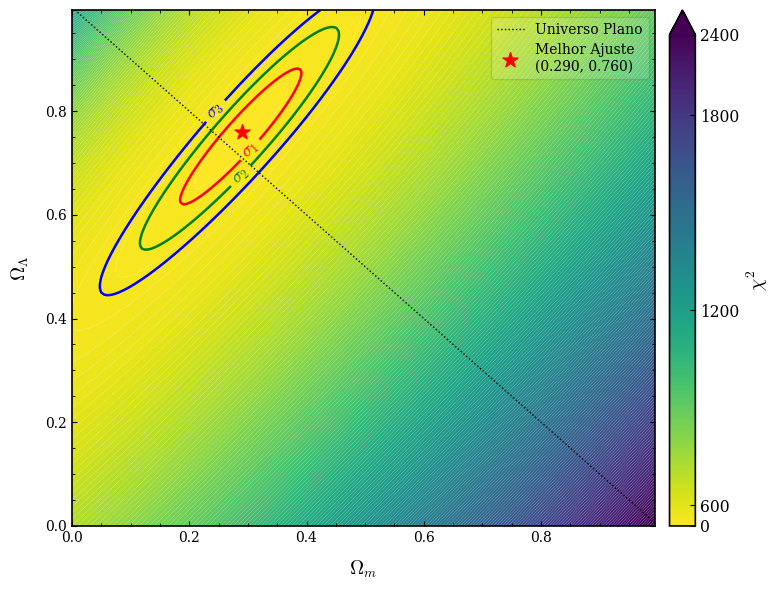

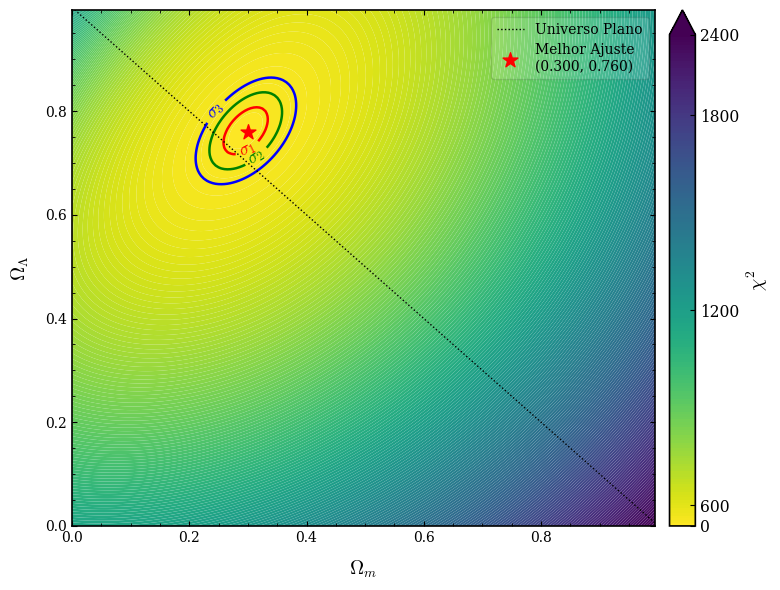

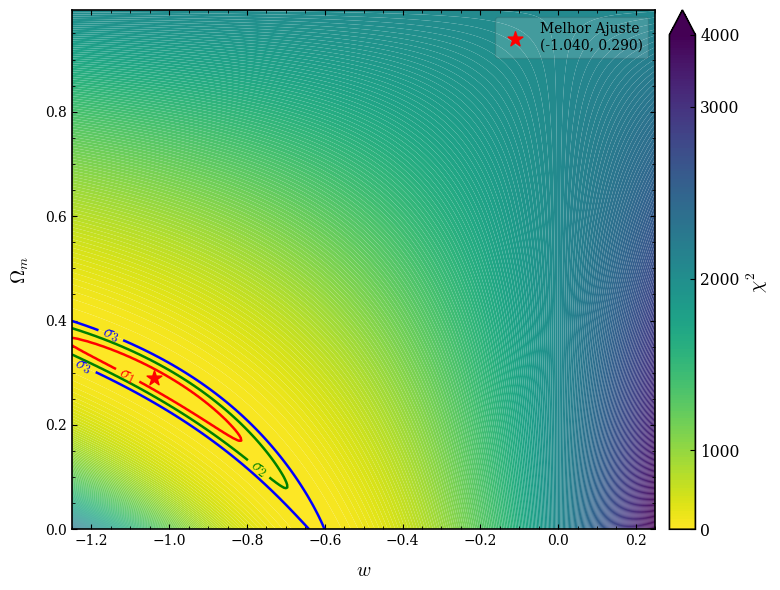

In [8]:

# ? -----------------------------------------------------------------------------
# ?         BIBLIOTECAS
# ? -----------------------------------------------------------------------------

import numpy as np

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

sy.header("Inferência de dados", Dados="obs_data.txt")

sy.status("Iniciando carregamento de dados...")
try:
    obsdatalist = sl.loadtable(
        "obs_data.txt", separator=sl.identificadora("obs_data.txt")
    )
    z_list = np.array(obsdatalist[0])
    mu_obs_list = np.array(obsdatalist[1])
    ERROmu_obs_list = np.array(obsdatalist[2])
    sy.ok(("z_list", "mu_obs_list", "ERROmu_obs_list"))
except Exception as e:
    sy.ok(f"Um erro foi encontrado ao tentar ler os dados observados. Erro: {e}", False)

# ? -----------------------------------------------------------------------------
# ?         VARREDURA UNIDIMENSIONAL
# ? -----------------------------------------------------------------------------

try:
    sy.status("Iniciando a varredura 1D...")
    omega_list = []
    omega_var = mesh_inter_omega[0]
    while omega_var < mesh_inter_omega[1]:
        omega_list.append(omega_var)
        omega_var = omega_var + meshgrid_step
    var1d = varredura_1D(omega_list, mu_obs_list, ERROmu_obs_list, z_list, w)
    chi_min = np.min(var1d[0])
    INDchi_min = np.argmin(var1d[0])
    sy.status("Varredura 1D concluida!")
except Exception as e:
    sy.ok(f"Um erro foi encontrado ao tentar realizar a varredura 1D. Erro: {e}", False)
try:
    sy.param(
        ("Qui-quadrado mínimo (chi2_min)", chi_min, "adm."),
        ("Densidade de materia Bestfit (BF_Omega_M)", var1d[1][INDchi_min], "adm."),
        ("Densidade de energia Bestfit (BF_Omega_EE)", var1d[2][INDchi_min], "adm."),
    )
    sy.status("Iniciando cálculo de incertezas...")
    chi_sigma1 = chi_min + 1
    chi_sigma2 = chi_min + 4
    chi_sigma3 = chi_min + 9
    R_INDchi_sigma1 = np.abs(var1d[0][INDchi_min:] - chi_sigma1).argmin() + INDchi_min
    L_INDchi_sigma1 = np.abs(var1d[0][:INDchi_min] - chi_sigma1).argmin()
    R_INDchi_sigma2 = np.abs(var1d[0][INDchi_min:] - chi_sigma2).argmin() + INDchi_min
    L_INDchi_sigma2 = np.abs(var1d[0][:INDchi_min] - chi_sigma2).argmin()
    R_INDchi_sigma3 = np.abs(var1d[0][INDchi_min:] - chi_sigma3).argmin() + INDchi_min
    L_INDchi_sigma3 = np.abs(var1d[0][:INDchi_min] - chi_sigma3).argmin()
    sy.param(
        ("Qui-quadrado 1_sigma (chi2_1_sigma)", chi_sigma1, "adm."),
        ("Qui-quadrado 2_sigma (chi2_2_sigma)", chi_sigma2, "adm."),
        ("Qui-quadrado 3_sigma (chi2_3_sigma)", chi_sigma3, "adm."),
    )
except Exception as e:
    sy.ok(f"Um erro foi encontrado ao tentar calcular as incertezas. Erro: {e}", False)
try:
    sy.status("Iniciando criação de gráfico de distribuição qui-quadrado...")
    deltachi1=var1d[1][INDchi_min]-var1d[1][L_INDchi_sigma1]
    deltachi2=var1d[1][INDchi_min]-var1d[1][L_INDchi_sigma2]
    deltachi3=var1d[1][INDchi_min]-var1d[1][L_INDchi_sigma3]
    gp.basicstyle(
        x_data=var1d[1],
        y_data=var1d[0],
        highlight_point=(var1d[1][INDchi_min], chi_min),
        title="",
        x_label=r"$\Omega_M$",
        y_label=r"$\chi^2$",
        save_fig=True,
        linestyle="--",
        highlight_label="Densidade de Matéria Bestfit",
        highlight_marker="|",
        highlight_size=200,
        curve_label=r"Distribuição de $\chi^2$",
        filename="CHIdistribuicao",
        show_plot=False,
        sigma_intervals=((var1d[1][INDchi_min]-deltachi1,var1d[1][INDchi_min]+deltachi1),(var1d[1][INDchi_min]-deltachi2,var1d[1][INDchi_min]+deltachi2),(var1d[1][INDchi_min]-deltachi3,var1d[1][INDchi_min]+deltachi3)),
        show_sigma_lines=True,
    )
    sy.ok(("Gráfico de distribuição qui-quadrado"))
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar plotar o gráfico de distribuição qui-quadrado. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         PROBABILIDADE DE ENERGIA ESCURA
# ? -----------------------------------------------------------------------------

try:
    sy.status("Iniciando cálculo da probabilidade de (Omega_EE > 0.5)...")
    prob_ee = veross1d(var1d[0], chi_min, var1d[2])
    if prob_ee > 0.5:
        ee1d = "confirmada!"
    else:
        ee1d = "não confirmada!"
    sy.param(
        ("Probabilidade de Energia Escura (P_ee)", prob_ee, "adm."),
        ("Energia Escura do universo superior a 50%", ee1d),
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar calcular a probabilidade de energia escura. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         VARREDURA BIDIMENSIONAL
# ? -----------------------------------------------------------------------------

try:
    sy.status("Iniciando a varredura 2D...")
    omegaM_list = []
    omegaM_var = mesh_inter_omega[0]
    while omegaM_var < mesh_inter_omega[1]:
        omegaM_list.append(omegaM_var)
        omegaM_var = omegaM_var + meshgrid_step
    omegaEE_list = omegaM_list
    var2d = varredura_2D(
        omegaM_list, omegaEE_list, mu_obs_list, ERROmu_obs_list, z_list, w
    )
    chi2d_min = np.min(var2d)
    MINDchi2d_min, EEINDchi2d_min = np.unravel_index(np.argmin(var2d), var2d.shape)
    sy.status("Varredura 2D concluida...")
except Exception as e:
    sy.ok(f"Um erro foi encontrado ao tentar realizar a varredura 2D. Erro: {e}", False)
try:
    sy.param(
        ("Qui-quadrado mínimo (2dchi2_min)", chi2d_min, "adm."),
        (
            "Densidade de materia Bestfit (2dBF_Omega_M)",
            omegaM_list[MINDchi2d_min],
            "adm.",
        ),
        (
            "Densidade de energia Bestfit (2dBF_Omega_EE)",
            omegaEE_list[EEINDchi2d_min],
            "adm.",
        ),
    )
    sy.status("Iniciando cálculo de incertezas...")
    chi2d_sigma1 = chi2d_min + 2.30
    chi2d_sigma2 = chi2d_min + 6.18
    chi2d_sigma3 = chi2d_min + 11.83
    sy.param(
        ("Qui-quadrado 1_sigma (chi2_1_sigma)", chi2d_sigma1),
        ("Qui-quadrado 2_sigma (chi2_2_sigma)", chi2d_sigma2),
        ("Qui-quadrado 3_sigma (chi2_3_sigma)", chi2d_sigma3),
    )
    niveis = [chi2d_sigma1, chi2d_sigma2, chi2d_sigma3]
except Exception as e:
    sy.ok(f"Um erro foi encontrado ao tentar calcular as incertezas. Erro: {e}", False)
try:
    sy.status("Iniciando criação de gráfico de distribuição qui-quadrado...")
    gp.elipse(
        x_data=omegaM_list,
        y_data=omegaEE_list,
        z_data=np.transpose(var2d),
        highlight_point=(
            round(omegaM_list[MINDchi2d_min], 2),
            round(omegaEE_list[EEINDchi2d_min], 2),
        ),
        ellipse_levels=niveis,
        sigma_names=(r"$\sigma_1$", r"$\sigma_2$", r"$\sigma_3$"),
        x_label=r"$\Omega_m$",
        y_label=r"$\Omega_\Lambda$",
        highlight_size=125,
        ellipse_styles=["-", "-", "-"],
        save_fig=True,
        show_grid=False,
        extra_line_x=omegaM_list,
        extra_line_y=1 - np.array(omegaM_list),
        extra_line_label="Universo Plano",
        legend_frame=True,
        colorbar_format="max",
        legend_alpha=0.15,
        legend_fontsize=10,
        colorbar_ticks=3,
        highlight_label="Melhor Ajuste",
        filename="mapadecalorMEE",
        show_plot=False,
    )
    sy.ok(("Gráfico de Distribuição de Qui-Quadrado"))
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar criar o gráfico de distribuição qui-quadrado. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         QUEBRA DE DEGENERECÊNCIA (PRIOR DA CMB)
# ? -----------------------------------------------------------------------------
try:

    sy.status(
        "Iniciando quebra de degenerescência: Aplicando Prior da CMB na malha 2D..."
    )
    var2dPRIOR = quebra_degenerecencia(
        omegaM_list, omegaEE_list, var2d, Omega_K_obs, ERROOmega_K_obs
    )
    chi2d_minPRIOR = np.min(var2dPRIOR)
    MINDchi2d_minPRIOR, EEINDchi2d_minPRIOR = np.unravel_index(
        np.argmin(var2dPRIOR), var2dPRIOR.shape
    )
    sy.param(
        (
            "Qui-quadrado mínimo com quebra de degenerecência (2dchi2_minPRIOR)",
            chi2d_minPRIOR,
        ),
        (
            "Densidade de materia Bestfit com quebra de degenerecência (2dBF_Omega_MPRIOR)",
            omegaM_list[MINDchi2d_minPRIOR],
        ),
        (
            "Densidade de energia Bestfit com quebra de degenerecência (2dBF_Omega_EEPRIOR)",
            omegaEE_list[EEINDchi2d_minPRIOR],
        ),
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar realizar a quebra de degenerecência. Erro: {e}",
        False,
    )
try:
    sy.status("Iniciando cálculo de incertezas")
    chi2d_sigma1PRIOR = chi2d_minPRIOR + 2.30
    chi2d_sigma2PRIOR = chi2d_minPRIOR + 6.18
    chi2d_sigma3PRIOR = chi2d_minPRIOR + 11.83
    sy.param(
        ("Qui-quadrado 1_sigma (chi2_1_sigma)", chi2d_sigma1PRIOR),
        ("Qui-quadrado 2_sigma (chi2_2_sigma)", chi2d_sigma2PRIOR),
        ("Qui-quadrado 3_sigma (chi2_3_sigma)", chi2d_sigma3PRIOR),
    )
    niveisPRIOR = [chi2d_sigma1PRIOR, chi2d_sigma2PRIOR, chi2d_sigma3PRIOR]
except Exception as e:
    sy.ok(f"Um erro foi encontrado ao tentar calcular as incertezas. Erro: {e}", False)
try:
    sy.status("Iniciando criação de gráfico de distribuição qui-quadrado corrigido...")

    gp.elipse(
        x_data=omegaM_list,
        y_data=omegaEE_list,
        z_data=np.transpose(var2dPRIOR),
        highlight_point=(
            round(omegaM_list[MINDchi2d_minPRIOR], 2),
            round(omegaEE_list[EEINDchi2d_minPRIOR], 2),
        ),
        ellipse_levels=niveisPRIOR,
        sigma_names=(r"$\sigma_1$", r"$\sigma_2$", r"$\sigma_3$"),
        x_label=r"$\Omega_m$",
        y_label=r"$\Omega_\Lambda$",
        highlight_size=125,
        ellipse_styles=["-", "-", "-"],
        save_fig=True,
        show_grid=False,
        extra_line_x=omegaM_list,
        extra_line_y=1 - np.array(omegaM_list),
        extra_line_label="Universo Plano",
        legend_frame=True,
        colorbar_format="max",
        legend_alpha=0.15,
        legend_fontsize=10,
        colorbar_ticks=3,
        highlight_label="Melhor Ajuste",
        filename="mapadecalormEEPRIOR",
        show_plot=False,
    )

    sy.ok(("Gráfico de Distribuição de Qui-Quadrado Corrigido"))
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar plotar o gráfico de distribuição qui-quadrado corrigido. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         PROBABILIDADE DE ACELERAÇÃO 2D
# ? -----------------------------------------------------------------------------

try:
    sy.status("Iniciando cálculo da probabilidade de aceleração")
    prob_aceleracao = veross2d(var2dPRIOR, chi2d_minPRIOR, omegaM_list, omegaEE_list, w)
    if prob_aceleracao > 0.997:
        acel = "confirmada!"
    else:
        acel = "não confirmada!"
    sy.param(
        ("Probabilidade de Aceleração (P_acel)", prob_aceleracao),
        ("Aceleração do universo superior a 3-sigma", acel),
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar calcular a probabilidade de aceleração. Erro: {e}",
        False,
    )

# ? -----------------------------------------------------------------------------
# ?         VARREDURA BIDIMENSIONAL - OMEGA_M VS W
# ? -----------------------------------------------------------------------------

try:
    sy.status("Iniciando varredura bidimensional (OMEGA_M vs W)...")
    w_list = []
    w_var = mesh_inter_w[0]
    while w_var < mesh_inter_w[1]:
        w_list.append(w_var)
        w_var = w_var + meshgrid_step
    var2dOW = varreduraOW(w_list, omegaM_list, mu_obs_list, ERROmu_obs_list, z_list)
    chi2dOW_min = np.min(var2dOW)
    WINDchi2dOW_min, MINDchi2dOW_min = np.unravel_index(
        np.argmin(var2dOW), var2dOW.shape
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar realizar a varredura bidimensional (OMEGA_M vs W). Erro: {e}",
        False,
    )
try:
    sy.status("Iniciando cálculo de parâmetros da varredura 2D (w vs Omega_M)...")
    sy.param(
        ("Qui-quadrado mínimo (2dchi2_min)", chi2dOW_min),
        ("Parâmetro da equação de estado Bestfit (2dBF_w)", w_list[WINDchi2dOW_min]),
        ("Densidade de matéria Bestfit (2dBF_Omega_M)", omegaM_list[MINDchi2dOW_min]),
    )
    sy.status("Iniciando cálculo de incertezas")
    chi2dOW_sigma1 = chi2dOW_min + 2.30
    chi2dOW_sigma2 = chi2dOW_min + 6.18
    chi2dOW_sigma3 = chi2dOW_min + 11.83
    sy.param(
        ("Qui-quadrado 1_sigma (chi2_1_sigma)", chi2dOW_sigma1),
        ("Qui-quadrado 2_sigma (chi2_2_sigma)", chi2dOW_sigma2),
        ("Qui-quadrado 3_sigma (chi2_3_sigma)", chi2dOW_sigma3),
    )
    niveis = [chi2dOW_sigma1, chi2dOW_sigma2, chi2dOW_sigma3]
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar calcular as incertezas. Erro: {e}",
        False,
    )
try:
    sy.status("Iniciando criação de gráfico de distribuição qui-quadrado")

    gp.elipse(
        x_data=w_list,
        y_data=omegaM_list,
        z_data=np.transpose(var2dOW),
        highlight_point=(
            round(w_list[WINDchi2dOW_min], 2),
            round(omegaM_list[MINDchi2dOW_min], 2),
        ),
        ellipse_levels=niveis,
        sigma_names=(r"$\sigma_1$", r"$\sigma_2$", r"$\sigma_3$"),
        y_label=r"$\Omega_m$",
        x_label=r"$w$",
        highlight_size=125,
        ellipse_styles=["-", "-", "-"],
        save_fig=True,
        show_grid=False,
        legend_frame=True,
        colorbar_format="max",
        legend_alpha=0.15,
        legend_fontsize=10,
        colorbar_ticks=3,
        highlight_label="Melhor Ajuste",
        filename="mapadecalorWM",
        show_plot=False,
    )
except Exception as e:
    sy.ok(
        f"Um erro foi encontrado ao tentar criar o gráfico de distribuição qui-quadrado. Erro: {e}",
        False,
    )

sy.fim()
